# Wine quality analysis

In [3]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [4]:
#load dataset
df = pd.read_csv(r"C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis/data/winequality.csv")

In [5]:
# shape
df.shape

(1599, 12)

In [6]:
# first few rows analysis
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# features of the df: 
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides	
- free sulfur dioxide	
- total sulfur dioxide	
- density	pH	sulphates
- alcohol

Target variable is : quality

In [7]:
# info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


there are no null values in the df

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Important Notes:
### Features have vastly different scales
- total sulfur dioxide ranges 6–289
- density ranges 0.99–1.003
### Skewness indicators
- residual sugar has a mean of 2.54 but a max of 15.5
- chlorides has a mean of 0.087 but max of 0.611
- total sulfur dioxide has mean 46 but max 289
- sulphates has mean 0.66 but max 2.0
### Outliers
- residual sugar, 75th is 2.6 but max is 15.5
- total sulfur dioxide, 75th is 62 but max is 289.

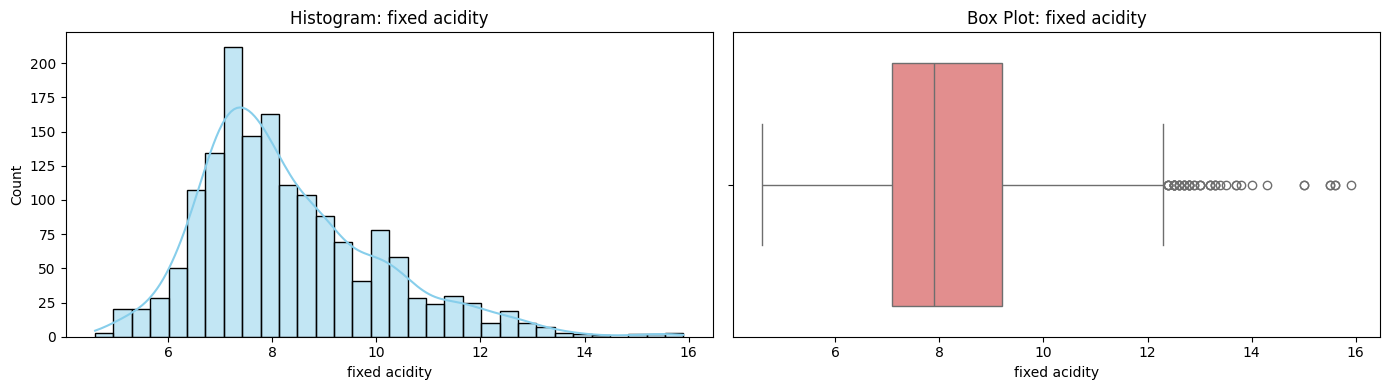

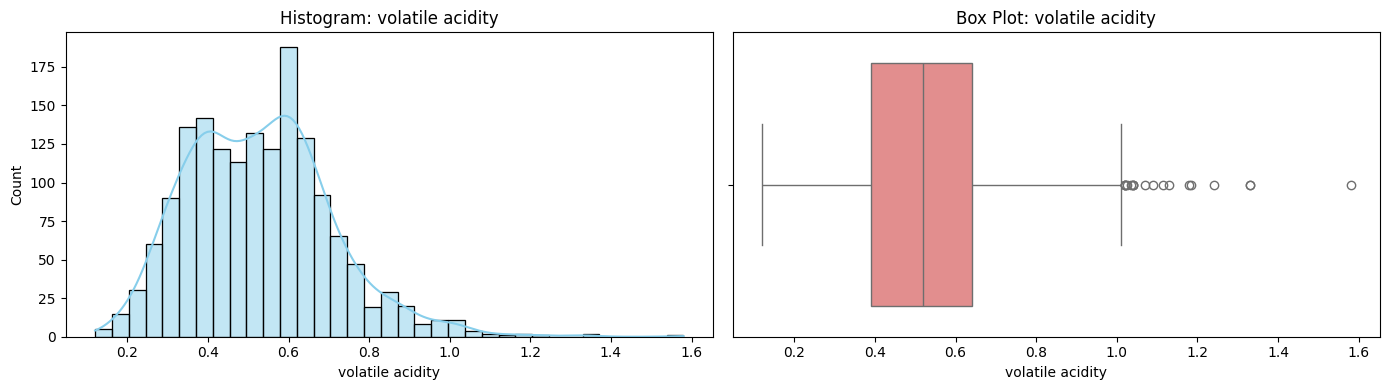

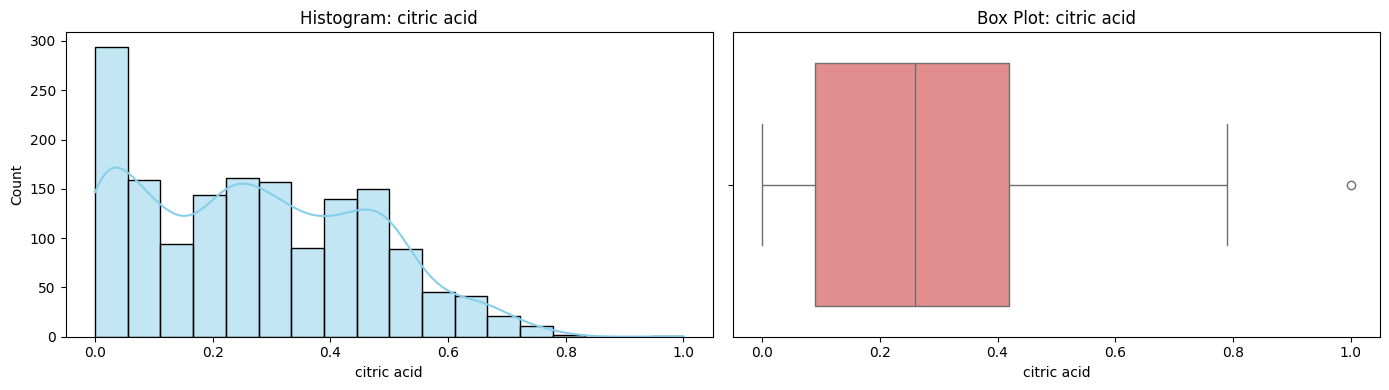

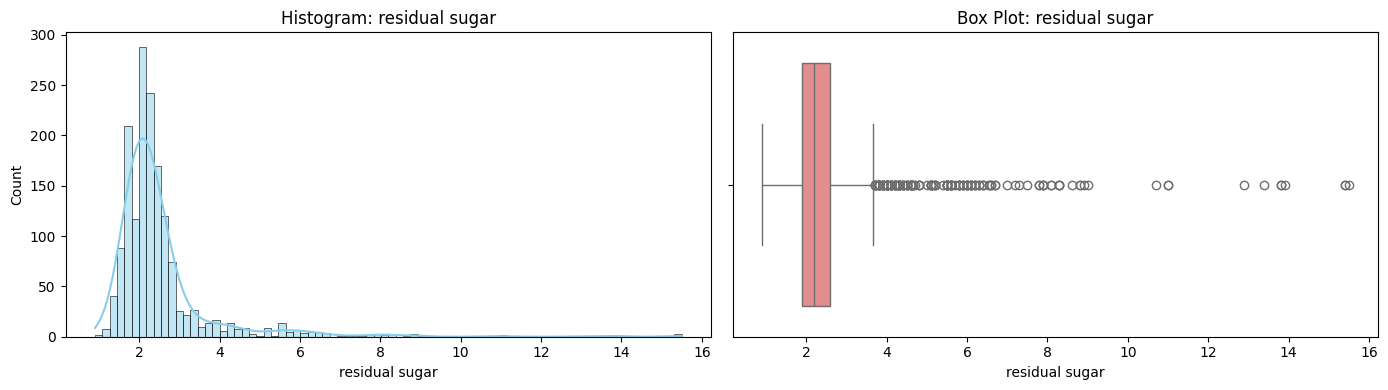

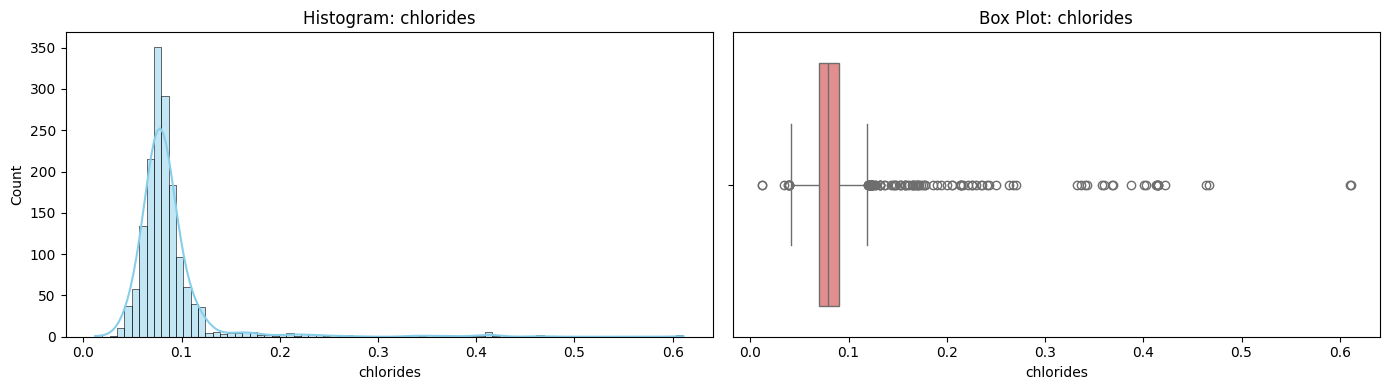

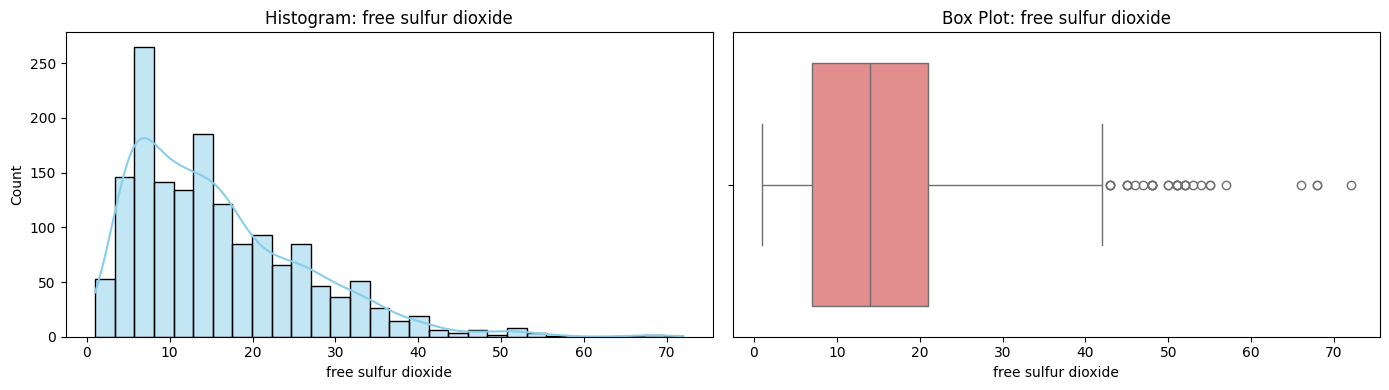

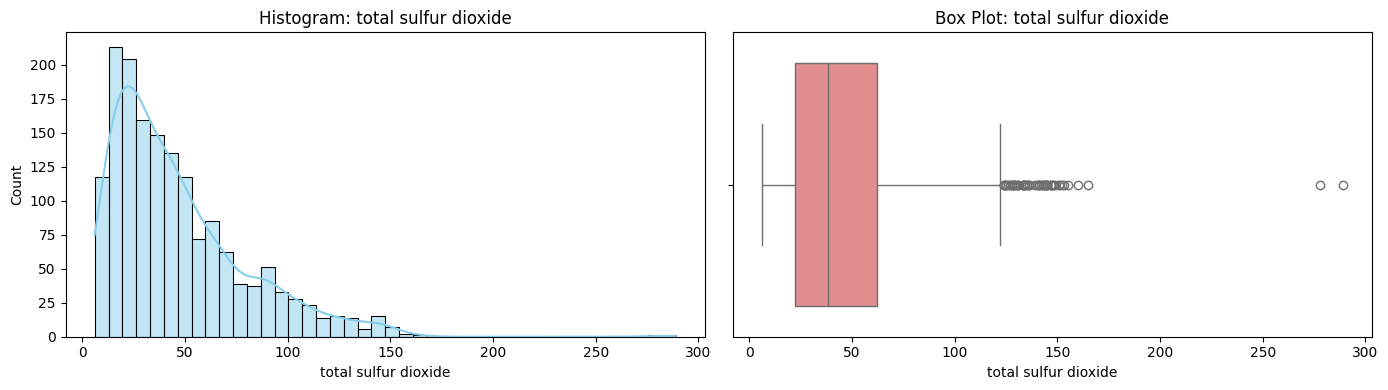

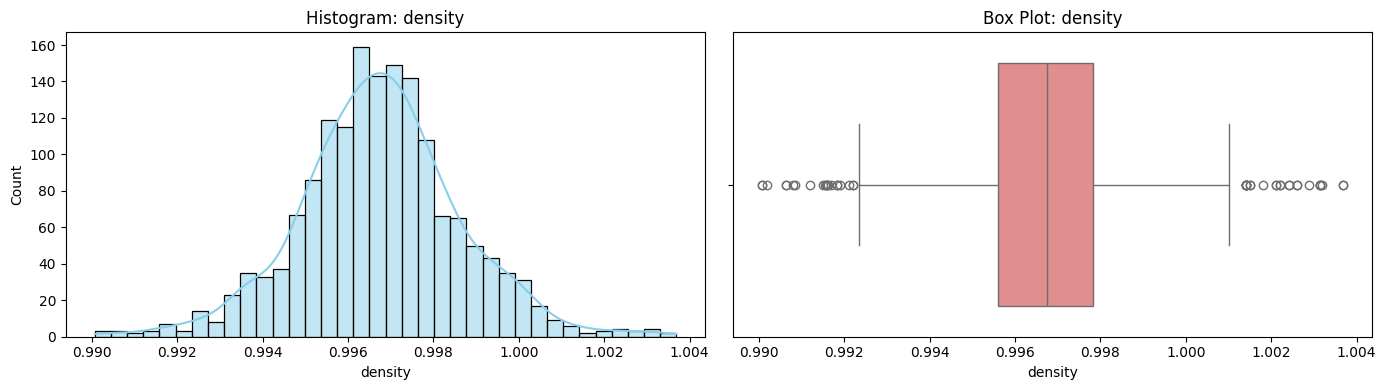

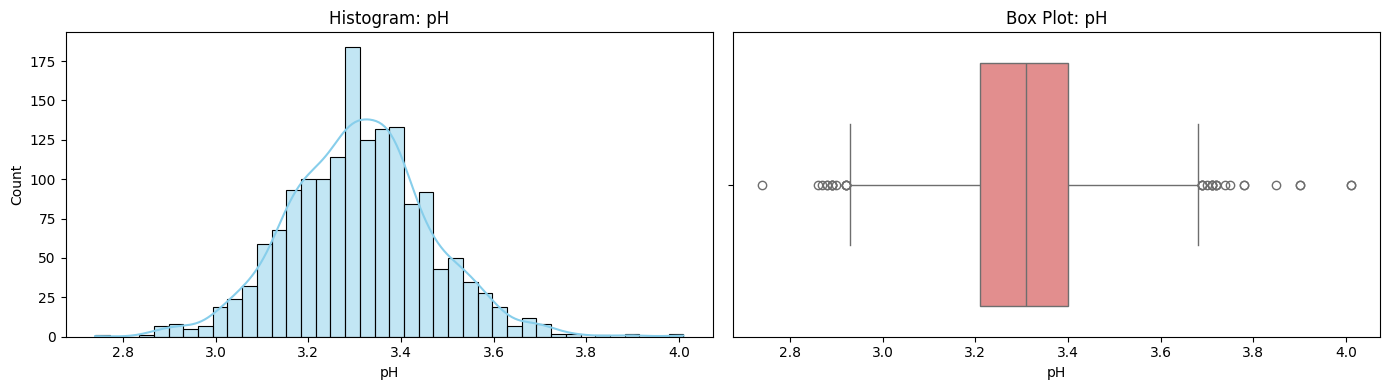

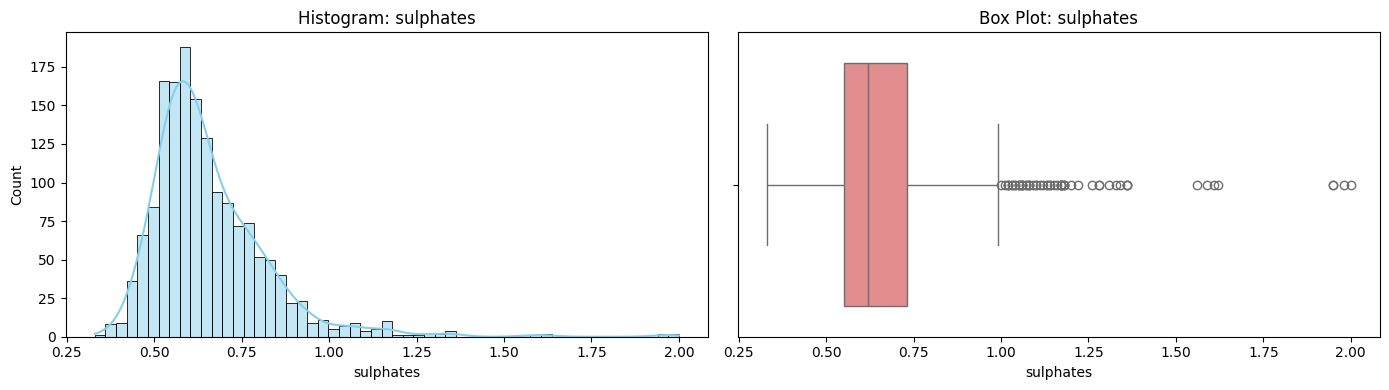

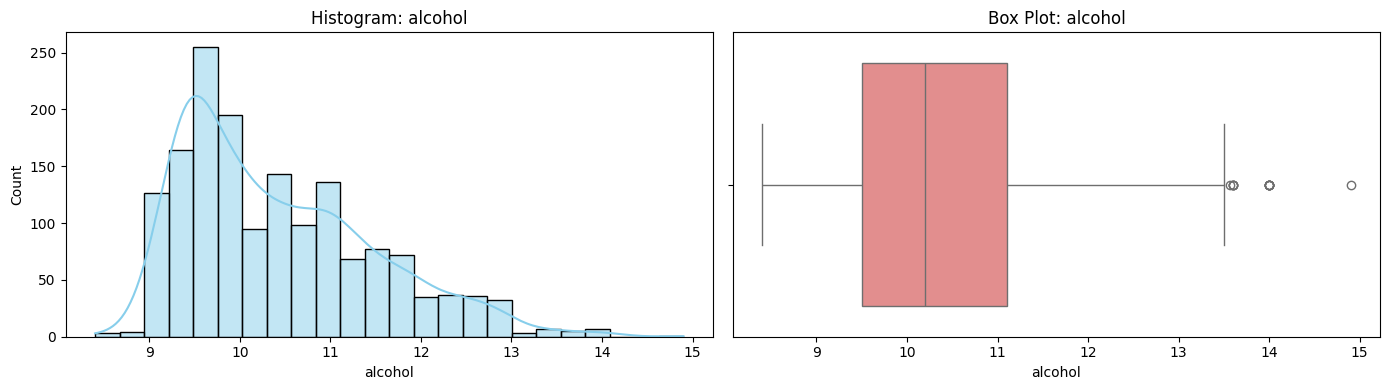

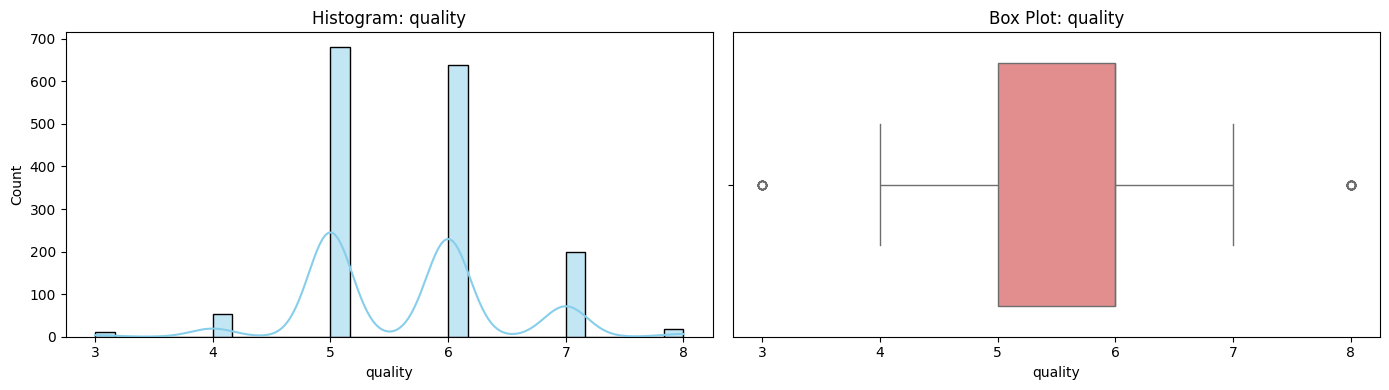

In [9]:
# plot histograms to see the distribution of columns
# 1. Select only the numeric columns (ignores text/categorical columns)
numeric_columns = df.select_dtypes(include=['number']).columns

# 2. Loop through each column and create the plots
for col in numeric_columns:
    # Create a figure with two subplots side-by-side
    plt.figure(figsize=(14, 4))
    
    # --- Histogram ---
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Histogram: {col}')
    
    # --- Box Plot ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box Plot: {col}')
    
    # Adjust layout so titles don't overlap
    plt.tight_layout()
    plt.show()

In [10]:
df["citric acid"].value_counts()

citric acid
0.00    132
0.49     68
0.24     51
0.02     50
0.26     38
       ... 
0.79      1
0.71      1
0.72      1
0.75      1
0.78      1
Name: count, Length: 80, dtype: int64

In [11]:
# splitting the data
from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # This ensures the distribution of 'y' is preserved
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1279, 11)
Test shape: (320, 11)


In [12]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Create, Fit, and Predict (The 3-line core)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

In [14]:
# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE
r2 = r2_score(y_test, y_pred)

# Display Results
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.4951
RMSE: 0.6375
R²:   0.3703


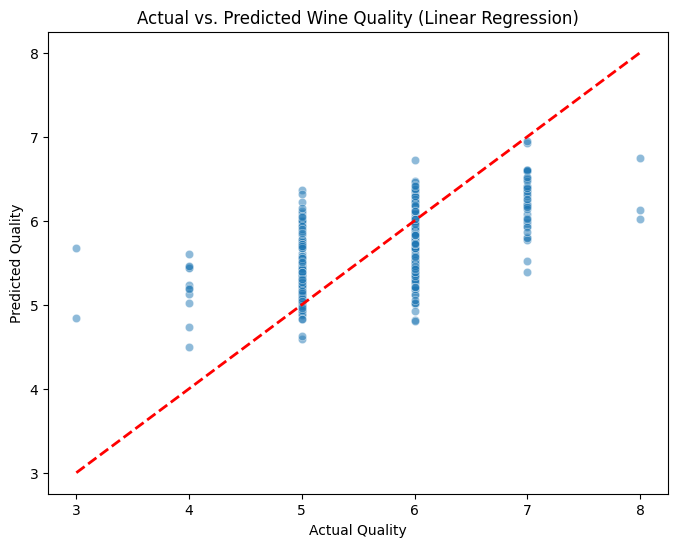

In [15]:
# plot the graph for linear regression

plt.figure(figsize=(8,6))

# Scatter plot of values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# plot the prediction line
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords,line_coords,color='red', linestyle='--',lw=2)

plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Actual vs. Predicted Wine Quality (Linear Regression)')
plt.show()

### Observation
There are very few samples of quality 3 and 8, so the model barely learns them. 
-  at quality 3, actual is 3 but the model predicts around 4.8–5.7. overestimates bad wines.
-  At quality 8, actual is 8 but predictions are around 6–6.7. It underestimates great wines
  
Means, the relationship between features and quality is not purely linear

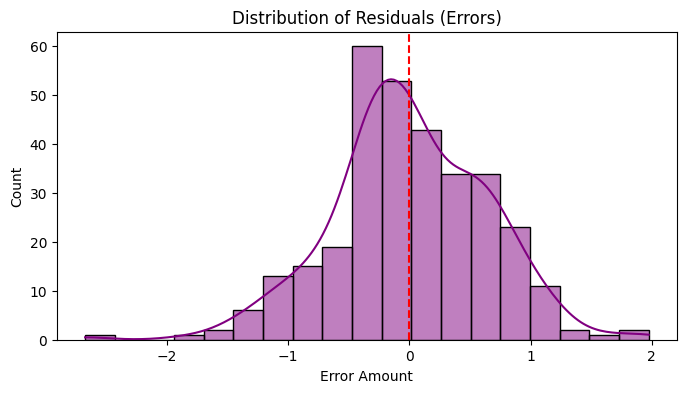

In [16]:
# plot the errors

residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error Amount')
plt.show()

The residuals have a normal distribution, centered near zero. 

### Take away from regression analysis
My regression analysis showed that linear models couldn't capture the complexity of wine quality prediction, particularly for extreme quality scores

## Logistic regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Create the model
# Increase max_iter because Logistic Regression might need more steps to converge on scaled data
log_reg = LogisticRegression(max_iter=1000)

# 2. Fit on training data
log_reg.fit(X_train_scaled, y_train)

# 3. Predict on test data
y_pred_log = log_reg.predict(X_test_scaled)

# 4. Evaluate
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy Score: 0.5906

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

### Notes
"Precision is ill-defined for labels with no predicted samples" means your model never predicted certain quality classes at all

The gap between macro avg and weighted avg tells the whole story. Weighted avg is 0.57 but macro avg is only 0.31. That gap means the model performs decently on majority classes but completely fails on minority classes. If someone only looked at accuracy (59%) or weighted avg, they'd think the model is okay. Macro avg reveals the truth

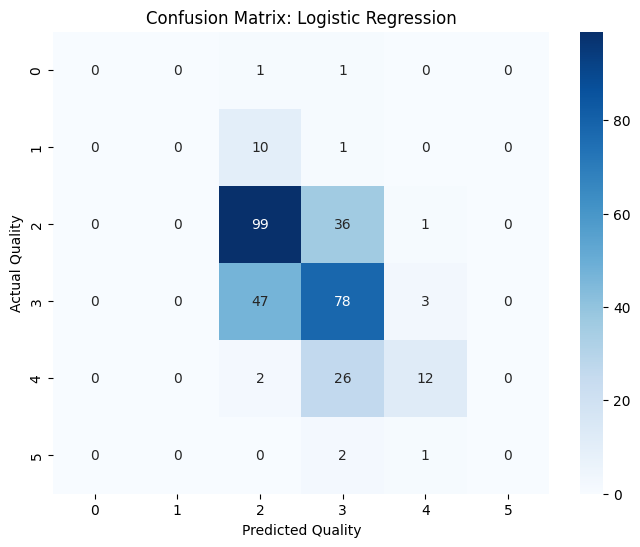

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

### Observation:
The confusion matrix reveals that Logistic Regression effectively only predicts two classes (quality 5 and 6), completely failing on minority classes (3, 4, 8). This is a classic symptom of class imbalance

should chose one of the following methods
- binary classification or
- applying class balancing techniques."

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize and Fit
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

# 2. Predict
y_pred_class = clf.predict(X_test_scaled)

# 3. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred_class):.2f}")
print(classification_report(y_test, y_pred_class))

Accuracy: 0.68
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saisa\Downloads\AI_ML_Assignment\wine-quality-ml-analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

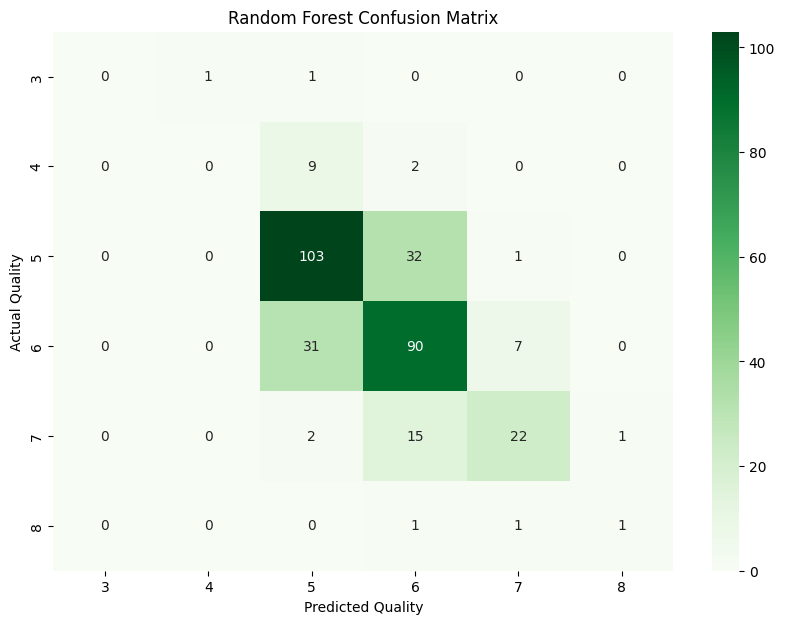

In [21]:
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

# 2. Plotting using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)

plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Take away
Random Forest significantly outperforms Logistic Regression across all metrics (accuracy 0.68 vs 0.59, macro recall 0.39 vs 0.27). The improvement is especially notable for quality 7 (recall 55% vs 30%), indicating Random Forest captures non-linear feature interactions that Logistic Regression misses. However, extreme minority classes (quality 3, 4) remain unpredictable due to insufficient training samples. Binary classification should address this limitation